<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Cleaning**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
df= pd.read_csv("/content/AB_NYC_2019.csv")
print(df.shape)
print(df.info())



(48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review         

In [3]:
print(df.describe())

                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1.680442   
min          1.000000           0.00

**Removing duplicate values**

In [4]:
print(df.duplicated().sum())

0


**Missing Data Handling**

In [5]:
print(df.isnull().sum())
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")
print("\nMissing values after cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing values after cleaning:
 last_review          10052
reviews_per_month    10052
dtype: int64


**Standardization**

In [6]:
# Standardize dates: convert 'last_review' from string to datetime object
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Standardize strings: strip leading/trailing whitespace and ensure consistent casing
df['room_type'] = df['room_type'].str.strip().str.title()
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip().str.title()

print("Standardized 'last_review' to format:", df['last_review'].dtype)
display(df[['room_type', 'neighbourhood_group']].head(3))

Standardized 'last_review' to format: datetime64[ns]


,room_type,neighbourhood_group
0,Private Room,Brooklyn
1,Entire Home/Apt,Manhattan
2,Private Room,Manhattan


**Outlier Detection**

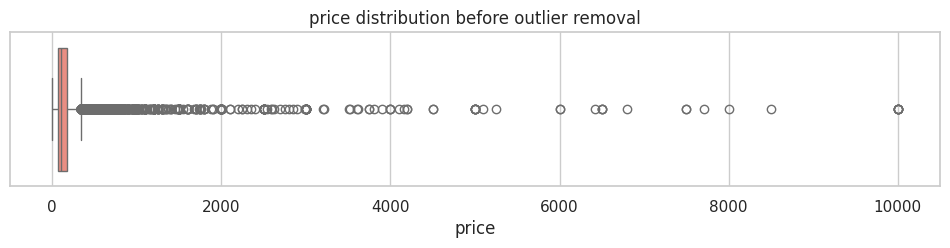


Original Row Count : 48895
Cleaned Row Count :45923
Removed 2972 outlier rows(extreme luxury properties)


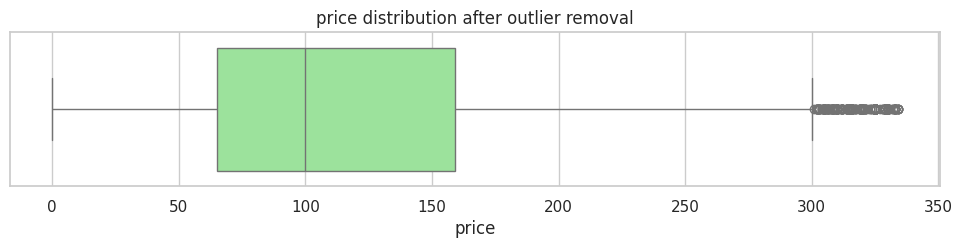

In [10]:
plt.figure(figsize=(12,2))
sns.boxplot(x=df['price'],color='salmon')
plt.title('price distribution before outlier removal')
plt.show()
#InterQuartileRange calculating for price
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df_cleaned=df[(df['price']>=0) & (df['price']<=upper_bound)]
print(f"\nOriginal Row Count : {df.shape[0]}")
print(f"Cleaned Row Count :{df_cleaned.shape[0]}")
print(f"Removed {df.shape[0] - df_cleaned.shape[0]} outlier rows(extreme luxury properties)")
plt.figure(figsize=(12,2))
sns.boxplot(x=df_cleaned['price'],color='lightgreen')
plt.title('price distribution after outlier removal')
plt.show()
